In [25]:
from geopy.distance import geodesic
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

## ***load initial csv***

In [24]:
df = pd.read_csv('grids.csv')
df.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km,distance_to_volos_port_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POLYGON ((22.479991203666504 39.59805048281335...,NaN,22.482951,39.595837,47.615963,47.638670
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POLYGON ((22.480089649443066 39.59354688377664...,NaN,22.483049,39.591333,47.344507,47.358359
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POLYGON ((22.48018807311691 39.589043281018085...,NaN,22.483148,39.586829,47.076799,47.081691
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POLYGON ((22.480286474693532 39.58453967453788...,NaN,22.483246,39.582326,46.812903,46.808731
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POLYGON ((22.480384854178418 39.58003606433615...,NaN,22.483344,39.577822,46.552884,46.539546


## ***insert: distance from center***

In [ ]:
volos_center = (39.3666, 22.9507)

In [8]:
# Compute distance from each grid centroid to Volos center
df['distance_to_volos_center_km'] = df.apply(
    lambda row: geodesic((row['centroid_lat'], row['centroid_lon']), volos_center).km,
    axis=1
)

In [9]:
df.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POLYGON ((22.479991203666504 39.59805048281335...,NaN,22.482951,39.595837,47.615963
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POLYGON ((22.480089649443066 39.59354688377664...,NaN,22.483049,39.591333,47.344507
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POLYGON ((22.48018807311691 39.589043281018085...,NaN,22.483148,39.586829,47.076799
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POLYGON ((22.480286474693532 39.58453967453788...,NaN,22.483246,39.582326,46.812903
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POLYGON ((22.480384854178418 39.58003606433615...,NaN,22.483344,39.577822,46.552884


In [12]:
# Closest to Volos center
df.nsmallest(5, 'distance_to_volos_center_km')[['id', 'centroid_lat', 'centroid_lon', 'distance_to_volos_center_km']]



,id,centroid_lat,centroid_lon,distance_to_volos_center_km
11332,11333.0,39.366750,22.952239,0.133677
11191,11192.0,39.366698,22.946436,0.367638
11333,11334.0,39.362245,22.952306,0.502889
11331,11332.0,39.371255,22.952172,0.532104
11192,11193.0,39.362193,22.946503,0.608429


In [13]:
# Farthest from Volos center
df.nlargest(5, 'distance_to_volos_center_km')[['id', 'centroid_lat', 'centroid_lon', 'distance_to_volos_center_km']]


,id,centroid_lat,centroid_lon,distance_to_volos_center_km
140,141.0,38.965296,22.496493,59.378245
281,282.0,38.965370,22.502263,59.043582
139,140.0,38.969800,22.496398,59.008643
422,423.0,38.965444,22.508032,58.711270
280,281.0,38.969874,22.502168,58.671871


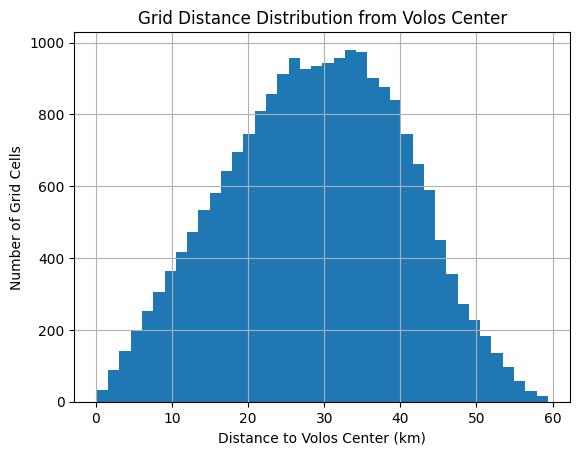

In [20]:
import matplotlib.pyplot as plt

df['distance_to_volos_center_km'].hist(bins=40)
plt.xlabel('Distance to Volos Center (km)')
plt.ylabel('Number of Grid Cells')
plt.title('Grid Distance Distribution from Volos Center')
plt.show()

In [10]:
df.to_csv("grids_with_volos_distance.csv", index=False)

## ***insert: distance from port***

In [16]:
volos_port = (39.35887819842874, 22.944538825211723)

In [17]:
# Compute distance from each grid centroid to Volos port
df['distance_to_volos_port_km'] = df.apply(
    lambda row: geodesic((row['centroid_lat'], row['centroid_lon']), volos_port).km,
    axis=1
)

In [18]:
df.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km,distance_to_volos_port_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POLYGON ((22.479991203666504 39.59805048281335...,NaN,22.482951,39.595837,47.615963,47.638670
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POLYGON ((22.480089649443066 39.59354688377664...,NaN,22.483049,39.591333,47.344507,47.358359
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POLYGON ((22.48018807311691 39.589043281018085...,NaN,22.483148,39.586829,47.076799,47.081691
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POLYGON ((22.480286474693532 39.58453967453788...,NaN,22.483246,39.582326,46.812903,46.808731
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POLYGON ((22.480384854178418 39.58003606433615...,NaN,22.483344,39.577822,46.552884,46.539546


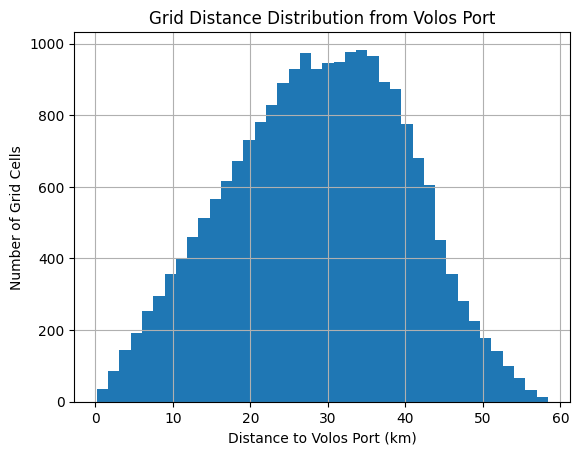

In [21]:
import matplotlib.pyplot as plt

df['distance_to_volos_port_km'].hist(bins=40)
plt.xlabel('Distance to Volos Port (km)')
plt.ylabel('Number of Grid Cells')
plt.title('Grid Distance Distribution from Volos Port')
plt.show()

In [22]:
df.to_csv("grids_with_volos_distance.csv", index=False)

## ***insert: distance from highway***

In [ ]:
# Convert df to GeoDataFrame
grid_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['centroid_lon'], df['centroid_lat']),
    crs="EPSG:4326"
)

In [27]:
# Load the main road shapefile
main_roads = gpd.read_file("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Gridding\\main roads shapefiles\\main_roads_magnesia.shp").to_crs("EPSG:4326")

In [28]:
# Combine all road lines into a single geometry object
road_union = main_roads.unary_union

C:\Users\Giorgos\AppData\Local\Temp\ipykernel_14836\75663235.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  road_union = main_roads.unary_union


In [29]:
from geopy.distance import geodesic

# Calculate geodesic distance (in km) from each centroid to the nearest point on the road network
def compute_distance_km(point):
    nearest_point = road_union.interpolate(road_union.project(point))
    return geodesic((point.y, point.x), (nearest_point.y, nearest_point.x)).km

In [30]:
grid_gdf['dist_to_main_road_km'] = grid_gdf['geometry'].apply(compute_distance_km)

In [31]:
grid_gdf.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POINT (22.48295 39.59584),NaN,22.482951,39.595837,47.615963,47.638670,49.588037
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POINT (22.48305 39.59133),NaN,22.483049,39.591333,47.344507,47.358359,49.309748
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POINT (22.48315 39.58683),NaN,22.483148,39.586829,47.076799,47.081691,49.034980
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POINT (22.48325 39.58233),NaN,22.483246,39.582326,46.812903,46.808731,48.763794
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POINT (22.48334 39.57782),NaN,22.483344,39.577822,46.552884,46.539546,48.496249


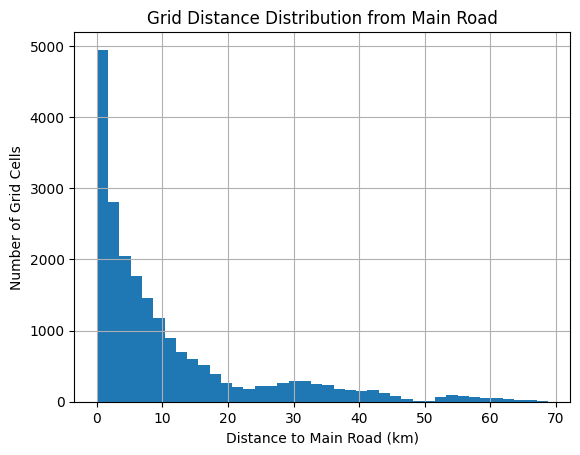

In [34]:
import matplotlib.pyplot as plt

grid_gdf['dist_to_main_road_km'].hist(bins=40)
plt.xlabel('Distance to Main Road (km)')
plt.ylabel('Number of Grid Cells')
plt.title('Grid Distance Distribution from Main Road')
plt.show()

In [40]:
df = pd.read_csv("grids.csv")

In [41]:
df['dist_to_main_road_km'] = grid_gdf['dist_to_main_road_km']

In [42]:
df.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POLYGON ((22.479991203666504 39.59805048281335...,NaN,22.482951,39.595837,47.615963,47.638670,49.588037
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POLYGON ((22.480089649443066 39.59354688377664...,NaN,22.483049,39.591333,47.344507,47.358359,49.309748
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POLYGON ((22.48018807311691 39.589043281018085...,NaN,22.483148,39.586829,47.076799,47.081691,49.034980
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POLYGON ((22.480286474693532 39.58453967453788...,NaN,22.483246,39.582326,46.812903,46.808731,48.763794
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POLYGON ((22.480384854178418 39.58003606433615...,NaN,22.483344,39.577822,46.552884,46.539546,48.496249


In [43]:
df.to_csv("grids_with_road_distance.csv", index=False)

## ***insert: distance from bus stop***

In [57]:
import geopandas as gpd
bus_stops = gpd.read_file("C:/Users/Giorgos/Desktop/HMMY/10ο Εξάμηνο/Διπλωματική/4. Gridding/shapefiles - transport stops/transport-clean.gpkg")

In [58]:
# Combine all bus stops into a single geometry collection
bus_union = bus_stops.unary_union

C:\Users\Giorgos\AppData\Local\Temp\ipykernel_14836\1027943568.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bus_union = bus_stops.unary_union


In [59]:
# Load grid CSV with centroid lat/lon
df = pd.read_csv("grids.csv")

# Create GeoDataFrame with centroid geometry
grid_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['centroid_lon'], df['centroid_lat']),
    crs="EPSG:4326"
)

In [60]:
from shapely.ops import nearest_points
from geopy.distance import geodesic

# Function to compute geodesic distance in km from a grid centroid to the nearest bus stop
def compute_distance_km(point):
    nearest_stop = nearest_points(point, bus_union)[1]
    return geodesic((point.y, point.x), (nearest_stop.y, nearest_stop.x)).km

In [61]:
# Apply the function to each grid centroid
grid_gdf['dist_to_bus_stop_km'] = grid_gdf['geometry'].apply(compute_distance_km)

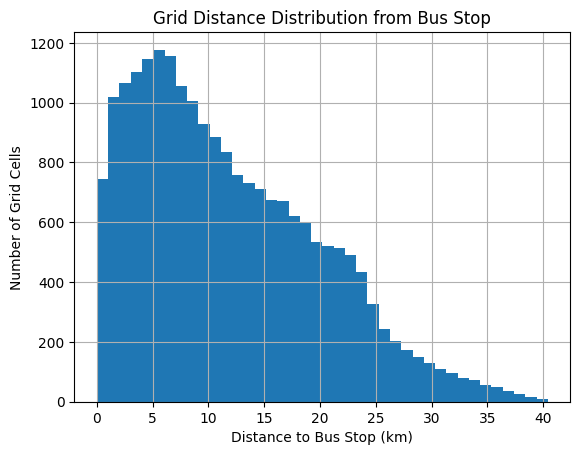

In [63]:
import matplotlib.pyplot as plt

grid_gdf['dist_to_bus_stop_km'].hist(bins=40)
plt.xlabel('Distance to Bus Stop (km)')
plt.ylabel('Number of Grid Cells')
plt.title('Grid Distance Distribution from Bus Stop')
plt.show()

In [62]:
grid_gdf.to_csv("grids_with_bus_stop_distance.csv", index=False)

In [64]:
df = pd.read_csv("grids.csv")

In [65]:
df['dist_to_bus_stop_km'] = grid_gdf['dist_to_bus_stop_km']

In [66]:
df.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POLYGON ((22.479991203666504 39.59805048281335...,NaN,22.482951,39.595837,47.615963,47.638670,49.588037,34.455856
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POLYGON ((22.480089649443066 39.59354688377664...,NaN,22.483049,39.591333,47.344507,47.358359,49.309748,34.116093
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POLYGON ((22.48018807311691 39.589043281018085...,NaN,22.483148,39.586829,47.076799,47.081691,49.034980,33.780316
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POLYGON ((22.480286474693532 39.58453967453788...,NaN,22.483246,39.582326,46.812903,46.808731,48.763794,33.448647
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POLYGON ((22.480384854178418 39.58003606433615...,NaN,22.483344,39.577822,46.552884,46.539546,48.496249,33.121209


In [67]:
df.to_csv("grids_with_bus_stop_distance.csv", index=False)

## ***insert: distance from university***

In [72]:
import geopandas as gpd
universities = gpd.read_file("C:/Users/Giorgos/Desktop/HMMY/10ο Εξάμηνο/Διπλωματική/4. Gridding/shapefiles - university/universities-magnesia.gpkg")

In [73]:
# Merge all university points into one geometry collection
uni_union = universities.unary_union

C:\Users\Giorgos\AppData\Local\Temp\ipykernel_14836\2462736085.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  uni_union = universities.unary_union


In [74]:
# Load grid CSV with centroid lat/lon
df = pd.read_csv("grids.csv")

# Create GeoDataFrame with centroid geometry
grid_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['centroid_lon'], df['centroid_lat']),
    crs="EPSG:4326"
)

In [75]:
# Compute distance to nearest university
def dist_to_university(point):
    nearest = nearest_points(point, uni_union)[1]
    return geodesic((point.y, point.x), (nearest.y, nearest.x)).km


In [76]:
grid_gdf['dist_to_university_km'] = grid_gdf['geometry'].apply(dist_to_university)

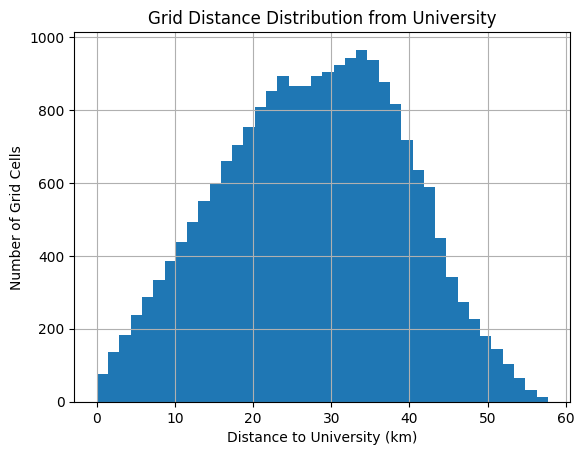

In [77]:
import matplotlib.pyplot as plt

grid_gdf['dist_to_university_km'].hist(bins=40)
plt.xlabel('Distance to University (km)')
plt.ylabel('Number of Grid Cells')
plt.title('Grid Distance Distribution from University')
plt.show()

In [78]:
df = pd.read_csv("grids.csv")

In [79]:
df['dist_to_university_km'] = grid_gdf['dist_to_university_km']

In [80]:
df.head()

,id,left,top,right,bottom,row_index,col_index,geometry,Municipal_Community,centroid_lon,centroid_lat,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,1.0,369341.6791,4.383963e+06,369841.6791,4.383463e+06,0.0,0.0,POLYGON ((22.479991203666504 39.59805048281335...,NaN,22.482951,39.595837,47.615963,47.638670,49.588037,34.455856,45.640860
1,2.0,369341.6791,4.383463e+06,369841.6791,4.382963e+06,1.0,0.0,POLYGON ((22.480089649443066 39.59354688377664...,NaN,22.483049,39.591333,47.344507,47.358359,49.309748,34.116093,45.384497
2,3.0,369341.6791,4.382963e+06,369841.6791,4.382463e+06,2.0,0.0,POLYGON ((22.48018807311691 39.589043281018085...,NaN,22.483148,39.586829,47.076799,47.081691,49.034980,33.780316,45.132221
3,4.0,369341.6791,4.382463e+06,369841.6791,4.381963e+06,3.0,0.0,POLYGON ((22.480286474693532 39.58453967453788...,NaN,22.483246,39.582326,46.812903,46.808731,48.763794,33.448647,44.884099
4,5.0,369341.6791,4.381963e+06,369841.6791,4.381463e+06,4.0,0.0,POLYGON ((22.480384854178418 39.58003606433615...,NaN,22.483344,39.577822,46.552884,46.539546,48.496249,33.121209,44.640202


In [81]:
df.to_csv("grids_with_university_distance.csv", index=False)